In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Sleep Health & Cognitive Performance Analysis

## Contents

1. Setup and Data Loading
2. Data Overview and Quality Audit
3. Univariate Analysis - Distribution of Key Features
4. Occupation Analysis - The Core Story
5. Correlation Analysis - What Drives Sleep Quality
6. Sleep Architecture Deep Dive
7. Lifestyle Factors Analysis
8. Statistical Hypothesis Testing
9. Feature Engineering
10. Target 1 - Binary Classification: Predicting `felt_rested`
11. Target 2 - Multiclass Classification: Predicting `sleep_disorder_risk`
12. Target 3 - Regression: Predicting `cognitive_performance_score`
13. Feature Importance and SHAP Analysis
14. Key Findings Summary

## 1. Setup and Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

# Plot style 
plt.rcParams.update({
    'figure.facecolor':  '#FAFAFA',
    'axes.facecolor':    '#FFFFFF',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.labelsize':    12,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'font.family':       'DejaVu Sans',
    'figure.dpi':        120,
})

PALETTE   = ['#185FA5', '#BA7517', '#3B6D11', '#534AB7', '#A32D2D', '#0F6E56']
BLUE      = '#185FA5'
GOLD      = '#BA7517'
GREEN     = '#3B6D11'
RED       = '#A32D2D'
DISORDER_COLORS = {'Healthy': '#3B6D11', 'Mild': '#BA7517', 'Moderate': '#E8893A', 'Severe': '#A32D2D'}
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
df = pd.read_csv('C:/Users/Super/PycharmProjects/MSiD/resources/sleep_health_dataset.csv')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head(3)

Shape: 100,000 rows x 32 columns
Memory usage: 60.6 MB
Missing values: 0


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0


## 2. Data Overview and Quality Audit

In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('person_id').tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'Numeric features : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')
print(f'Target columns   : cognitive_performance_score, sleep_disorder_risk, felt_rested')
print()

# Summary statistics for key sleep features
key_sleep = ['sleep_duration_hrs','sleep_quality_score','rem_percentage',
             'deep_sleep_percentage','sleep_latency_mins','wake_episodes_per_night']
df[key_sleep].describe().round(2)

Numeric features : 23
Categorical features: 8
Target columns   : cognitive_performance_score, sleep_disorder_risk, felt_rested



,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,6.42,4.87,20.24,20.25,19.84,3.35
std,1.27,1.51,3.41,4.25,7.58,1.92
min,3.00,1.00,10.00,5.00,1.00,0.00
25%,5.53,3.80,18.00,17.40,14.00,2.00
50%,6.36,4.90,20.30,20.30,19.00,3.00
75%,7.27,6.00,22.60,23.20,25.00,5.00
max,10.50,10.00,30.00,30.00,58.00,8.00


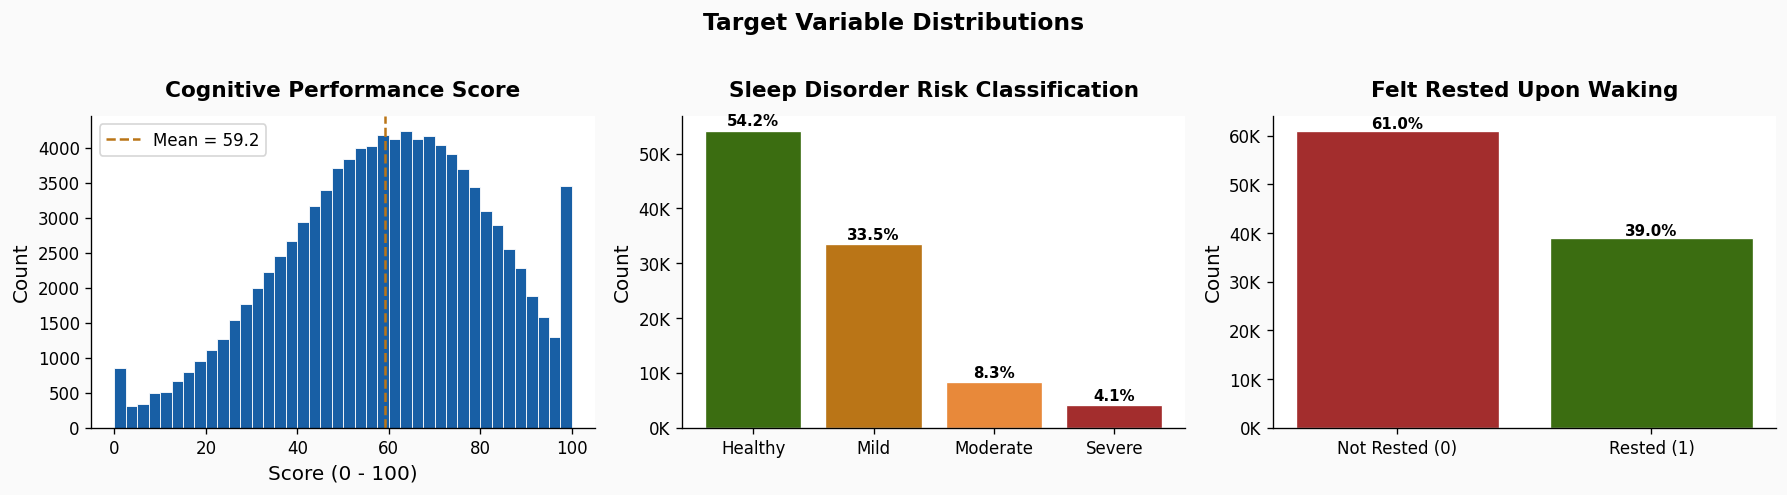

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Target Variable Distributions', fontsize=14, fontweight='bold', y=1.02)

# Target 1: cognitive_performance_score
axes[0].hist(df['cognitive_performance_score'], bins=40, color=BLUE, edgecolor='white', linewidth=0.5)
axes[0].axvline(df['cognitive_performance_score'].mean(), color=GOLD, linestyle='--', linewidth=1.5, label=f'Mean = {df["cognitive_performance_score"].mean():.1f}')
axes[0].set_title('Cognitive Performance Score')
axes[0].set_xlabel('Score (0 - 100)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Target 2: sleep_disorder_risk
order    = ['Healthy', 'Mild', 'Moderate', 'Severe']
counts   = df['sleep_disorder_risk'].value_counts().reindex(order)
colors_d = [DISORDER_COLORS[c] for c in order]
bars = axes[1].bar(order, counts.values, color=colors_d, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
                 f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Sleep Disorder Risk Classification')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Target 3: felt_rested
rested_counts = df['felt_rested'].value_counts().sort_index()
axes[2].bar(['Not Rested (0)', 'Rested (1)'], rested_counts.values,
            color=[RED, GREEN], edgecolor='white', linewidth=0.8)
for i, (label, val) in enumerate(zip(['Not Rested', 'Rested'], rested_counts.values)):
    axes[2].text(i, val + 400, f'{val/len(df)*100:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Felt Rested Upon Waking')
axes[2].set_ylabel('Count')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

## 3. Univariate Analysis - Distribution of Key Features

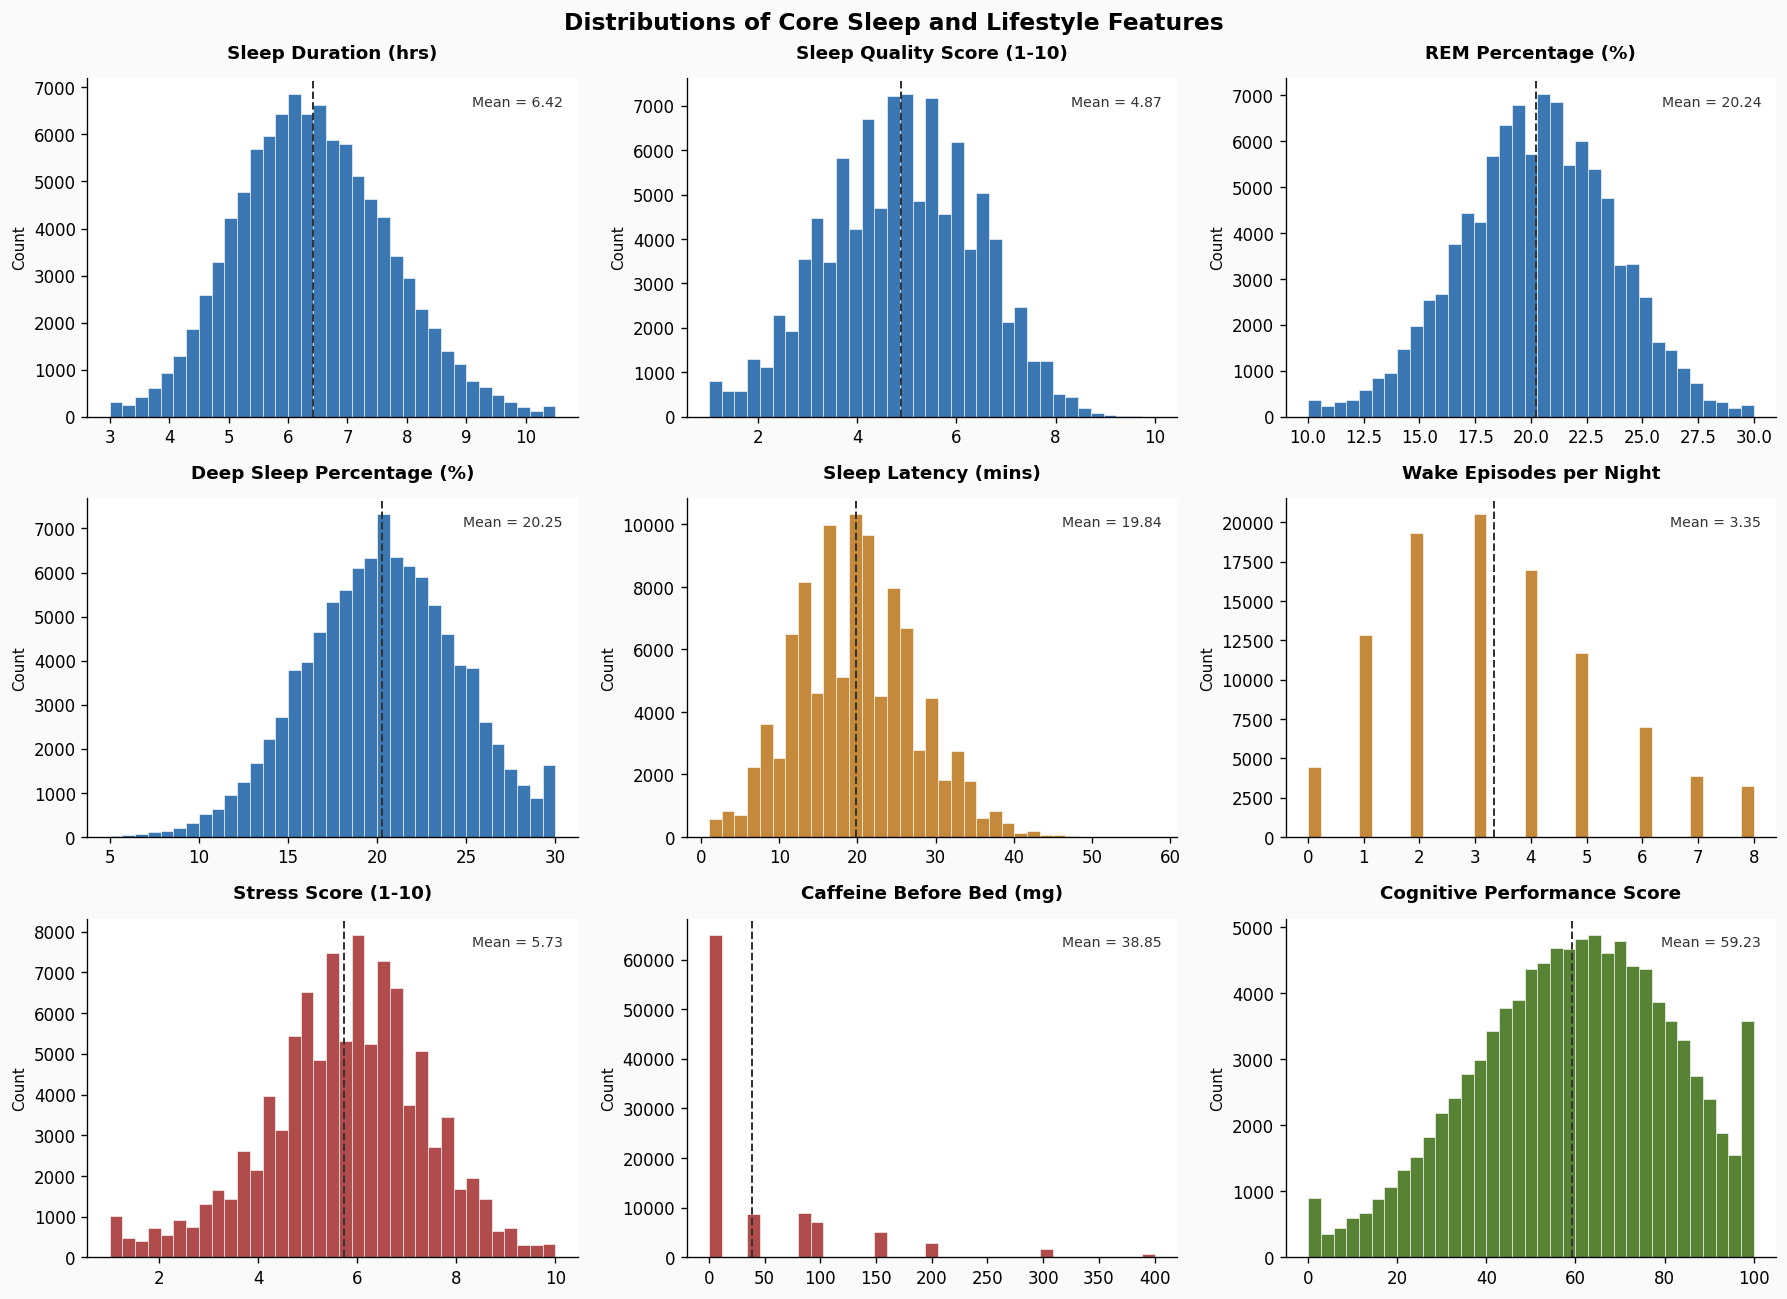

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
fig.suptitle('Distributions of Core Sleep and Lifestyle Features', fontsize=14, fontweight='bold')

features = [
    ('sleep_duration_hrs',         'Sleep Duration (hrs)',        BLUE),
    ('sleep_quality_score',        'Sleep Quality Score (1-10)',  BLUE),
    ('rem_percentage',             'REM Percentage (%)',          BLUE),
    ('deep_sleep_percentage',      'Deep Sleep Percentage (%)',   BLUE),
    ('sleep_latency_mins',         'Sleep Latency (mins)',        GOLD),
    ('wake_episodes_per_night',    'Wake Episodes per Night',     GOLD),
    ('stress_score',               'Stress Score (1-10)',         RED),
    ('caffeine_mg_before_bed',     'Caffeine Before Bed (mg)',    RED),
    ('cognitive_performance_score','Cognitive Performance Score', GREEN),
]

for ax, (col, label, color) in zip(axes.flat, features):
    ax.hist(df[col], bins=35, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(df[col].mean(), color='#333333', linestyle='--', linewidth=1.2)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=9)
    mean_txt = f'Mean = {df[col].mean():.2f}'
    ax.text(0.97, 0.95, mean_txt, transform=ax.transAxes,
            ha='right', va='top', fontsize=8.5, color='#333333')

plt.tight_layout()
plt.show()

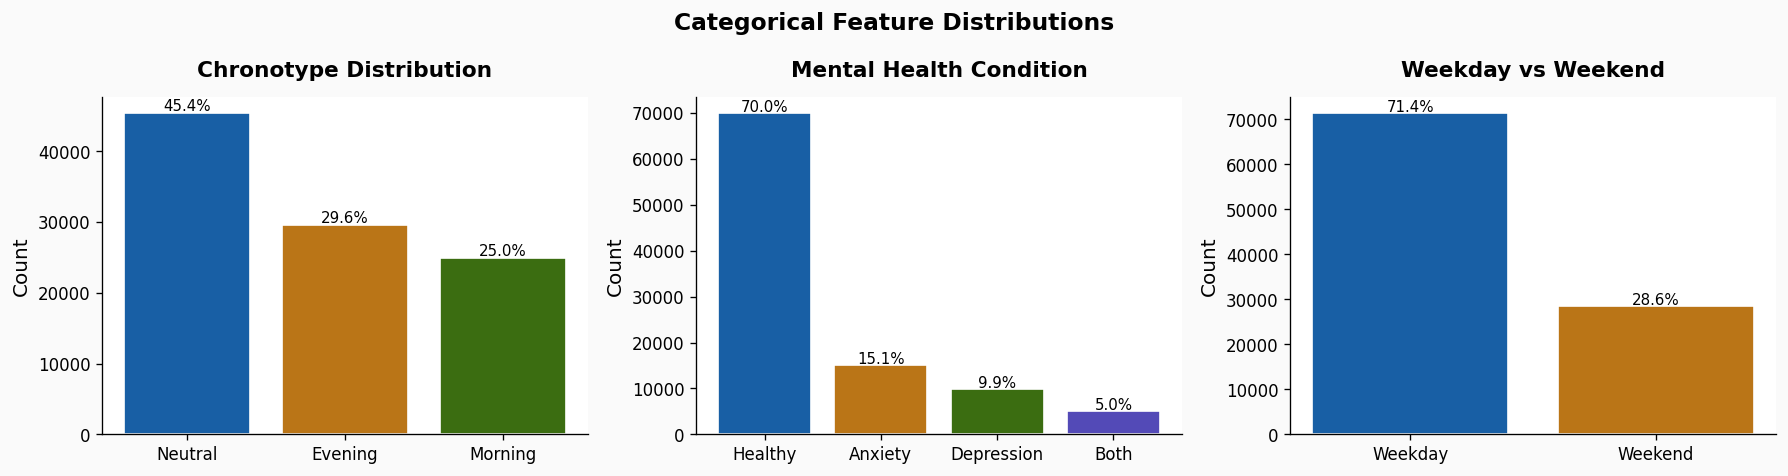

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')

# Chronotype
ct = df['chronotype'].value_counts()
axes[0].bar(ct.index, ct.values, color=PALETTE[:3], edgecolor='white')
axes[0].set_title('Chronotype Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(ct.values):
    axes[0].text(i, v + 300, f'{v/len(df)*100:.1f}%', ha='center', fontsize=9)

# Mental health condition
mh = df['mental_health_condition'].value_counts()
axes[1].bar(mh.index, mh.values, color=PALETTE[:4], edgecolor='white')
axes[1].set_title('Mental Health Condition')
axes[1].set_ylabel('Count')
for i, v in enumerate(mh.values):
    axes[1].text(i, v + 300, f'{v/len(df)*100:.1f}%', ha='center', fontsize=9)

# Day type
dt = df['day_type'].value_counts()
axes[2].bar(dt.index, dt.values, color=[BLUE, GOLD], edgecolor='white')
axes[2].set_title('Weekday vs Weekend')
axes[2].set_ylabel('Count')
for i, v in enumerate(dt.values):
    axes[2].text(i, v + 300, f'{v/len(df)*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Occupation Analysis - The Core Story

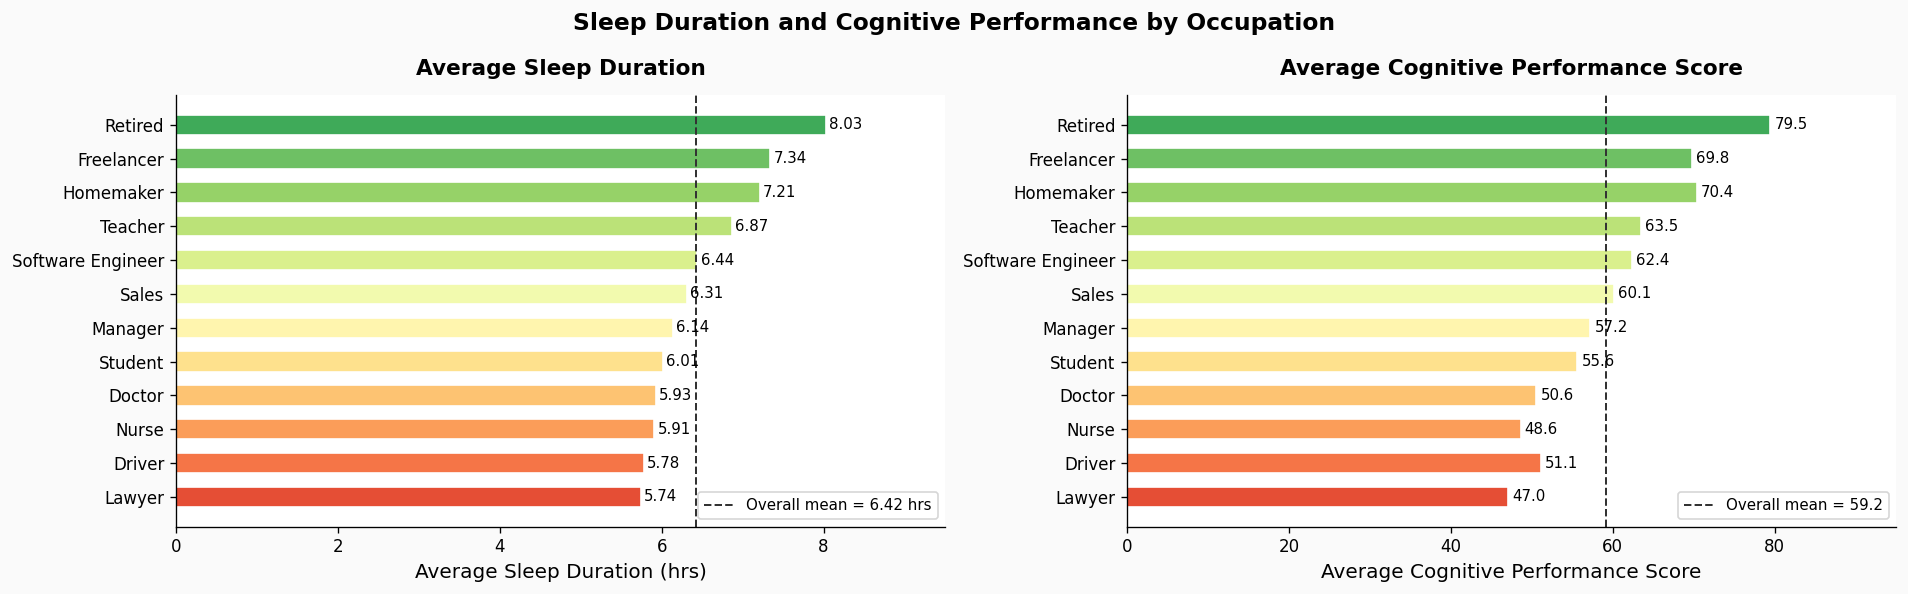


Largest sleep gap: Retired (8.03 hrs) vs Lawyer (5.74 hrs) = 2.29 hrs difference
Largest cognitive gap: Retired (79.5) vs Lawyer (47.0) = 32.4 points difference


In [8]:
occ_stats = df.groupby('occupation').agg(
    sleep_hrs         = ('sleep_duration_hrs',          'mean'),
    sleep_quality     = ('sleep_quality_score',          'mean'),
    stress            = ('stress_score',                 'mean'),
    cognitive         = ('cognitive_performance_score',  'mean'),
    n                 = ('person_id',                    'count')
).round(2).sort_values('sleep_hrs')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Sleep Duration and Cognitive Performance by Occupation', fontsize=14, fontweight='bold')

# Sleep duration
colors_occ = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(occ_stats)))
bars = axes[0].barh(occ_stats.index, occ_stats['sleep_hrs'], color=colors_occ, edgecolor='white', height=0.6)
axes[0].axvline(df['sleep_duration_hrs'].mean(), color='#333333', linestyle='--', linewidth=1.2, label=f'Overall mean = {df["sleep_duration_hrs"].mean():.2f} hrs')
for bar, val in zip(bars, occ_stats['sleep_hrs']):
    axes[0].text(val + 0.04, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)
axes[0].set_xlabel('Average Sleep Duration (hrs)')
axes[0].set_title('Average Sleep Duration')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_xlim(0, 9.5)

# Cognitive score
bars2 = axes[1].barh(occ_stats.index, occ_stats['cognitive'], color=colors_occ, edgecolor='white', height=0.6)
axes[1].axvline(df['cognitive_performance_score'].mean(), color='#333333', linestyle='--', linewidth=1.2, label=f'Overall mean = {df["cognitive_performance_score"].mean():.1f}')
for bar, val in zip(bars2, occ_stats['cognitive']):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9)
axes[1].set_xlabel('Average Cognitive Performance Score')
axes[1].set_title('Average Cognitive Performance Score')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_xlim(0, 95)

plt.tight_layout()
plt.show()

print(f'\nLargest sleep gap: Retired ({occ_stats["sleep_hrs"]["Retired"]:.2f} hrs) vs Lawyer ({occ_stats["sleep_hrs"]["Lawyer"]:.2f} hrs) = {occ_stats["sleep_hrs"]["Retired"] - occ_stats["sleep_hrs"]["Lawyer"]:.2f} hrs difference')
print(f'Largest cognitive gap: Retired ({occ_stats["cognitive"]["Retired"]:.1f}) vs Lawyer ({occ_stats["cognitive"]["Lawyer"]:.1f}) = {occ_stats["cognitive"]["Retired"] - occ_stats["cognitive"]["Lawyer"]:.1f} points difference')

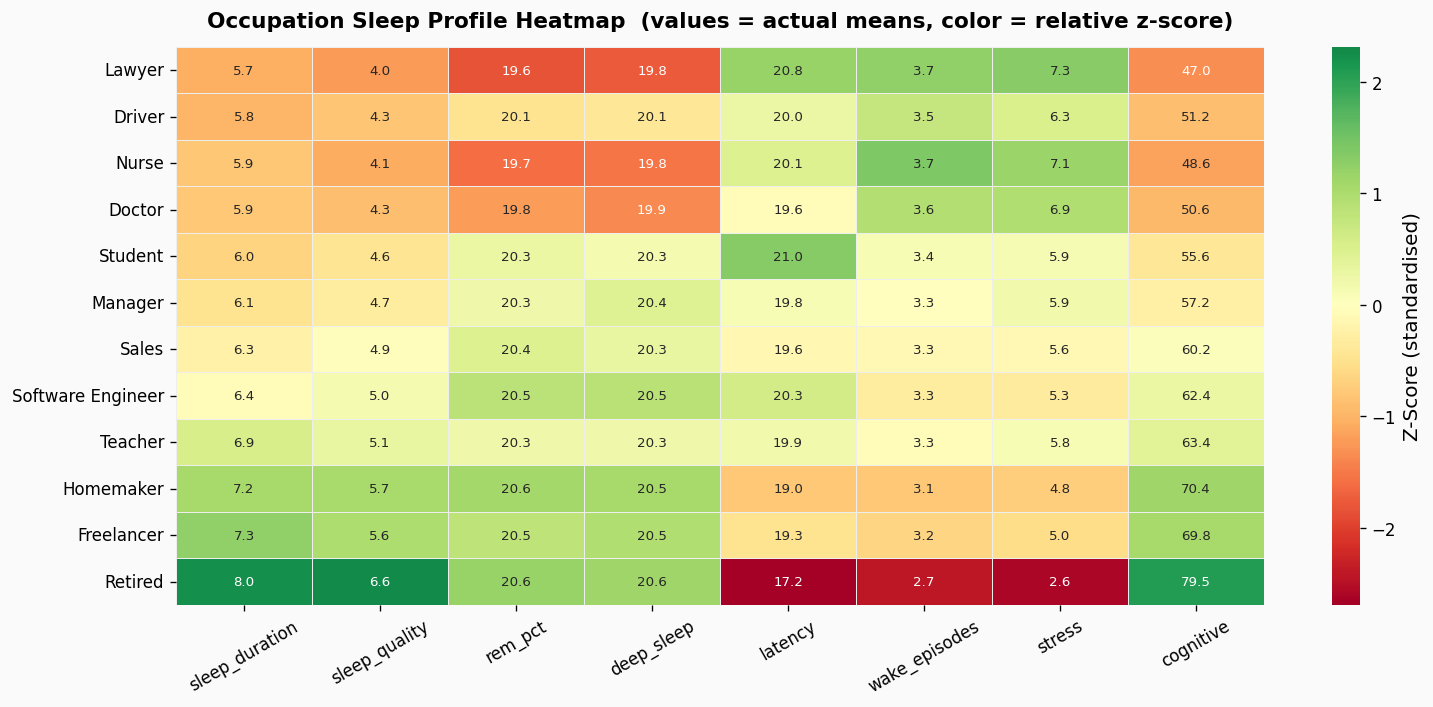

In [9]:
occ_multi = df.groupby('occupation').agg(
    sleep_duration    = ('sleep_duration_hrs',         'mean'),
    sleep_quality     = ('sleep_quality_score',        'mean'),
    rem_pct           = ('rem_percentage',             'mean'),
    deep_sleep        = ('deep_sleep_percentage',      'mean'),
    latency           = ('sleep_latency_mins',         'mean'),
    wake_episodes     = ('wake_episodes_per_night',    'mean'),
    stress            = ('stress_score',               'mean'),
    cognitive         = ('cognitive_performance_score','mean'),
).round(2).sort_values('sleep_duration')

# Z-score normalise for heatmap
from scipy.stats import zscore
occ_norm = occ_multi.apply(zscore)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    occ_norm,
    ax=ax,
    cmap='RdYlGn',
    center=0,
    annot=occ_multi.round(1),
    fmt='.1f',
    annot_kws={'size': 8},
    linewidths=0.5,
    linecolor='#EEEEEE',
    cbar_kws={'label': 'Z-Score (standardised)'}
)
ax.set_title('Occupation Sleep Profile Heatmap  (values = actual means, color = relative z-score)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

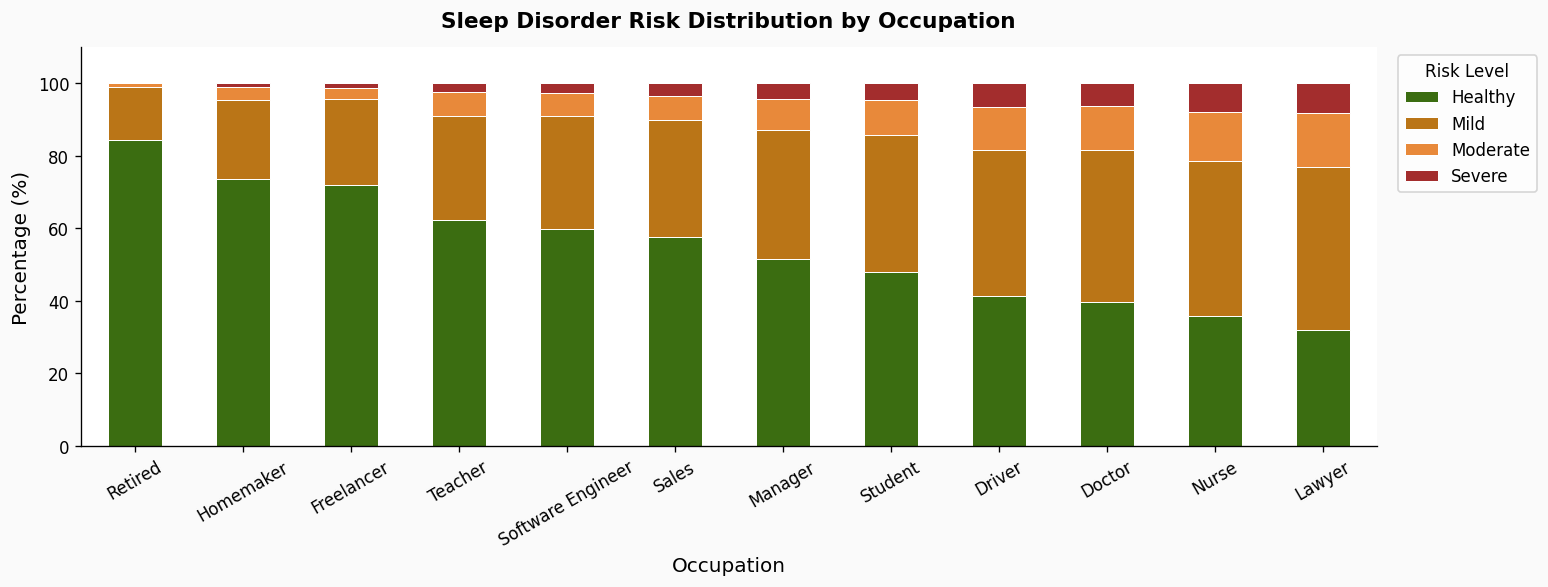

In [10]:
disorder_occ = df.groupby('occupation')['sleep_disorder_risk'] \
    .value_counts(normalize=True) \
    .unstack() \
    .reindex(columns=['Healthy','Mild','Moderate','Severe']) \
    .fillna(0) \
    .sort_values('Healthy', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
disorder_occ.multiply(100).plot(
    kind='bar', stacked=True, ax=ax,
    color=[DISORDER_COLORS[c] for c in disorder_occ.columns],
    edgecolor='white', linewidth=0.6
)
ax.set_title('Sleep Disorder Risk Distribution by Occupation', fontsize=13, fontweight='bold')
ax.set_xlabel('Occupation')
ax.set_ylabel('Percentage (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Risk Level', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

## 5. Correlation Analysis - What Drives Sleep Quality and Cognitive Performance

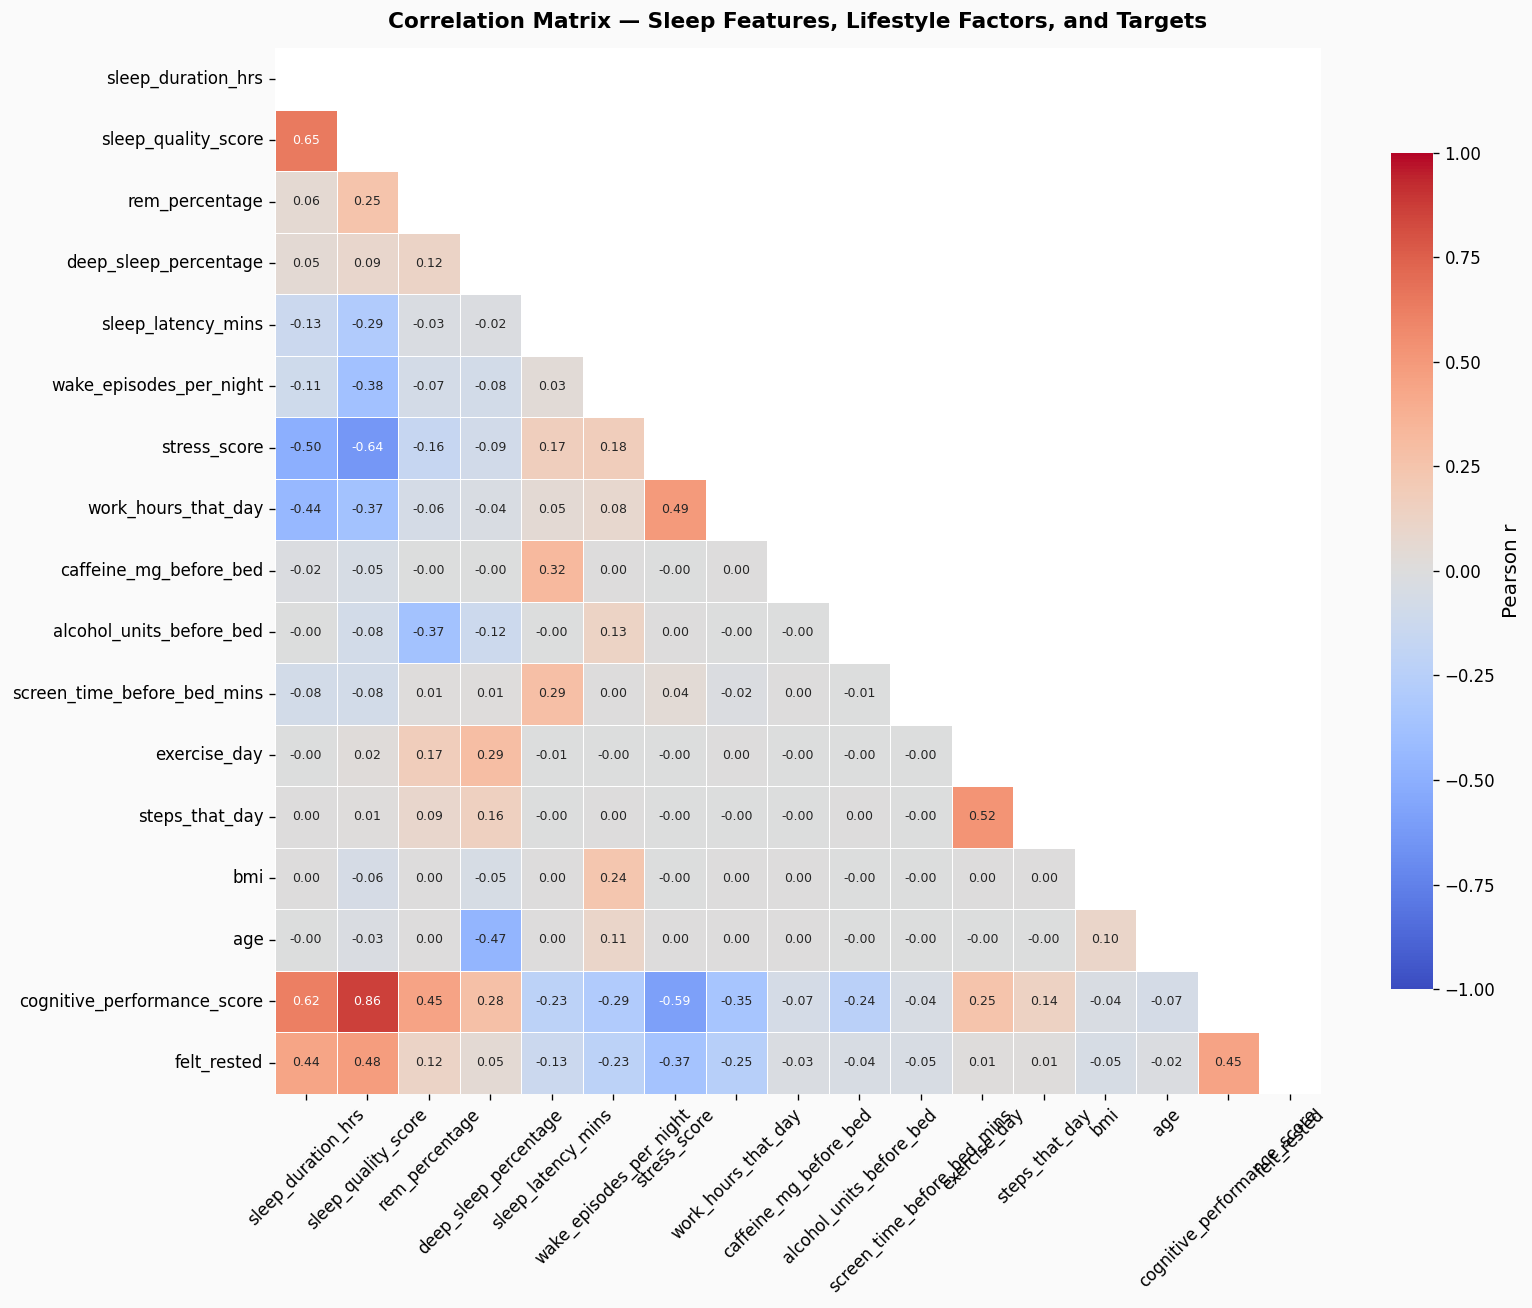

In [11]:
corr_cols = [
    'sleep_duration_hrs','sleep_quality_score','rem_percentage','deep_sleep_percentage',
    'sleep_latency_mins','wake_episodes_per_night','stress_score','work_hours_that_day',
    'caffeine_mg_before_bed','alcohol_units_before_bed','screen_time_before_bed_mins',
    'exercise_day','steps_that_day','bmi','age',
    'cognitive_performance_score','felt_rested'
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    ax=ax,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7.5},
    square=True,
    linewidths=0.4,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
ax.set_title('Correlation Matrix — Sleep Features, Lifestyle Factors, and Targets', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

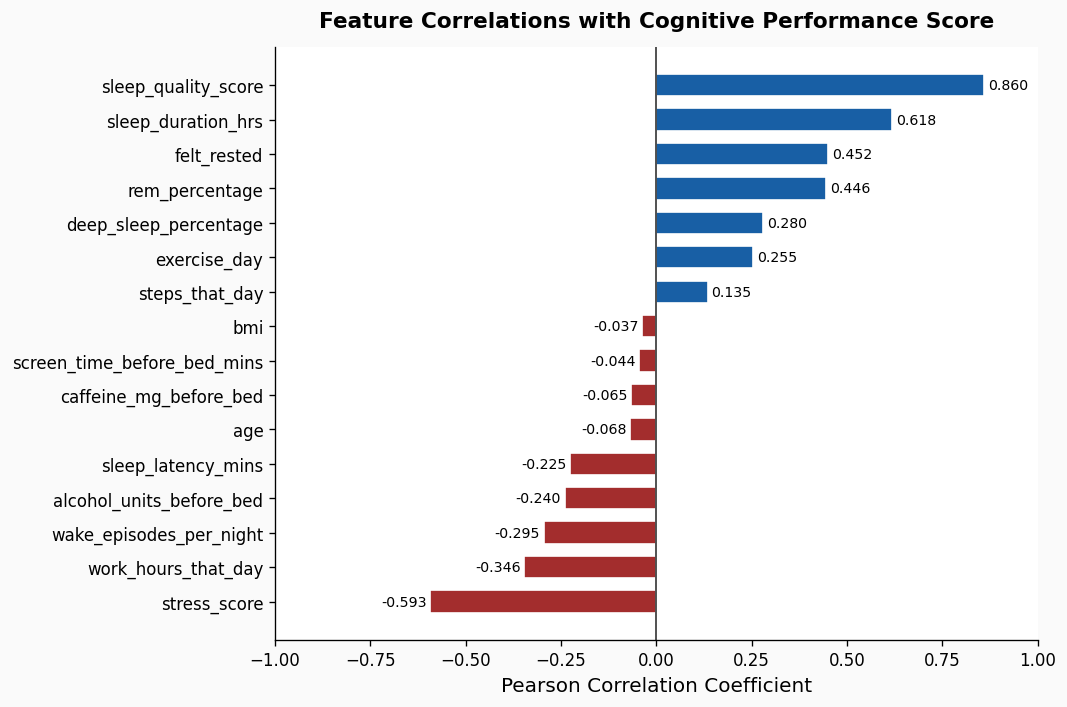

Top 3 positive predictors:
felt_rested            0.451526
sleep_duration_hrs     0.618241
sleep_quality_score    0.859978

Top 3 negative predictors:
stress_score              -0.592584
work_hours_that_day       -0.345869
wake_episodes_per_night   -0.294673


In [12]:
# Top correlations with cognitive_performance_score
cog_corr = df[corr_cols].corr()['cognitive_performance_score'].drop('cognitive_performance_score').sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = [RED if v < 0 else BLUE for v in cog_corr.values]
bars = ax.barh(cog_corr.index, cog_corr.values, color=colors_bar, edgecolor='white', height=0.65)
ax.axvline(0, color='#333333', linewidth=1)
for bar, val in zip(bars, cog_corr.values):
    xpos = val + 0.01 if val >= 0 else val - 0.01
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', ha=ha, fontsize=8.5)
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_title('Feature Correlations with Cognitive Performance Score', fontsize=13, fontweight='bold')
ax.set_xlim(-1.0, 1.0)
plt.tight_layout()
plt.show()

print('Top 3 positive predictors:')
print(cog_corr.tail(3).to_string())
print('\nTop 3 negative predictors:')
print(cog_corr.head(3).to_string())

## 6. Sleep Architecture Deep Dive

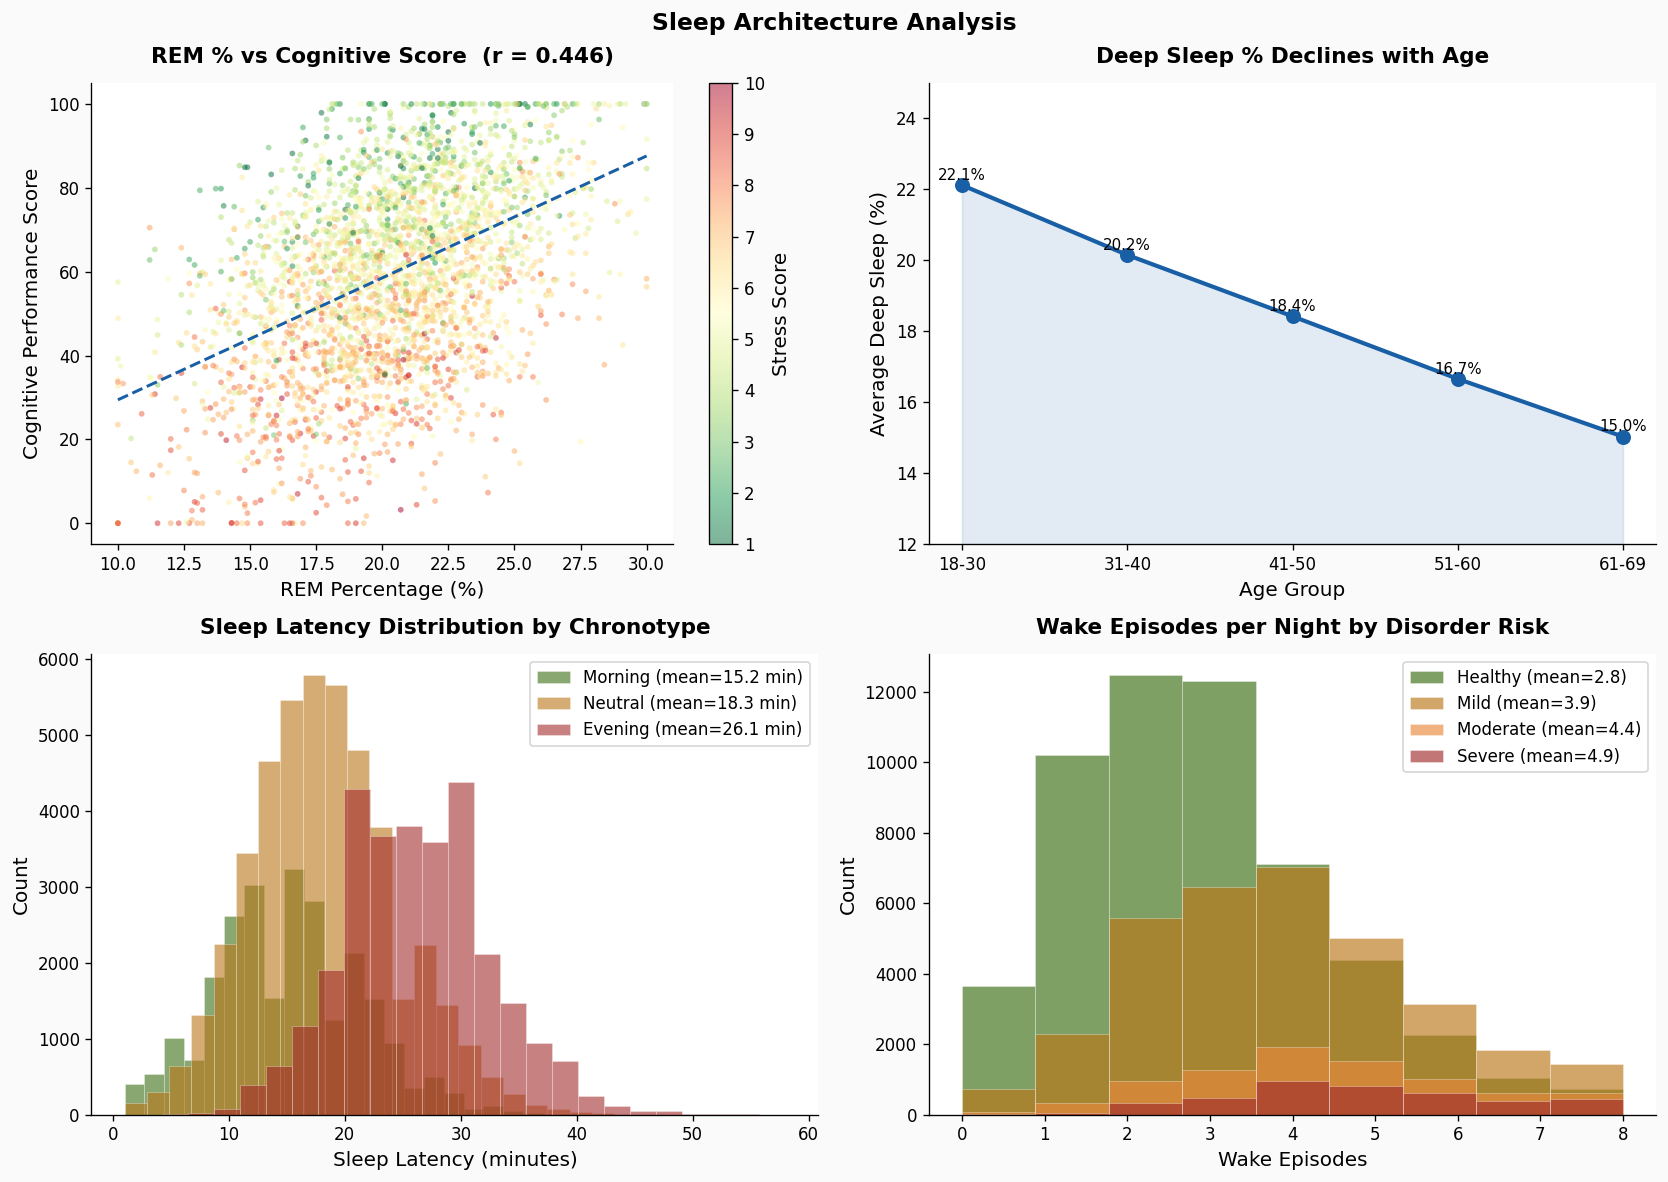

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sleep Architecture Analysis', fontsize=14, fontweight='bold')

# REM % vs Cognitive Score
sample = df.sample(3000, random_state=42)
sc = axes[0,0].scatter(
    sample['rem_percentage'],
    sample['cognitive_performance_score'],
    c=sample['stress_score'], cmap='RdYlGn_r',
    alpha=0.5, s=12, linewidths=0
)
plt.colorbar(sc, ax=axes[0,0], label='Stress Score')
m, b = np.polyfit(df['rem_percentage'], df['cognitive_performance_score'], 1)
x_line = np.linspace(df['rem_percentage'].min(), df['rem_percentage'].max(), 100)
axes[0,0].plot(x_line, m*x_line+b, color=BLUE, linewidth=1.8, linestyle='--')
r_val = df['rem_percentage'].corr(df['cognitive_performance_score'])
axes[0,0].set_title(f'REM % vs Cognitive Score  (r = {r_val:.3f})')
axes[0,0].set_xlabel('REM Percentage (%)')
axes[0,0].set_ylabel('Cognitive Performance Score')

# Deep sleep % by age bin
df['age_bin'] = pd.cut(df['age'], bins=[17,30,40,50,60,70], labels=['18-30','31-40','41-50','51-60','61-69'])
age_deep = df.groupby('age_bin', observed=True)['deep_sleep_percentage'].mean()
axes[0,1].plot(age_deep.index.astype(str), age_deep.values, marker='o', color=BLUE, linewidth=2.5, markersize=8)
axes[0,1].fill_between(range(len(age_deep)), age_deep.values, alpha=0.12, color=BLUE)
for i, (label, val) in enumerate(age_deep.items()):
    axes[0,1].text(i, val + 0.15, f'{val:.1f}%', ha='center', fontsize=9)
axes[0,1].set_title('Deep Sleep % Declines with Age')
axes[0,1].set_xlabel('Age Group')
axes[0,1].set_ylabel('Average Deep Sleep (%)')
axes[0,1].set_ylim(12, 25)

# Sleep latency by chronotype
for chron, color in zip(['Morning','Neutral','Evening'], [GREEN, GOLD, RED]):
    data = df[df['chronotype'] == chron]['sleep_latency_mins']
    axes[1,0].hist(data, bins=25, alpha=0.6, color=color, label=f'{chron} (mean={data.mean():.1f} min)', edgecolor='white', linewidth=0.3)
axes[1,0].set_title('Sleep Latency Distribution by Chronotype')
axes[1,0].set_xlabel('Sleep Latency (minutes)')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# Wake episodes by disorder risk
for risk, color in DISORDER_COLORS.items():
    data = df[df['sleep_disorder_risk'] == risk]['wake_episodes_per_night']
    axes[1,1].hist(data, bins=9, alpha=0.65, color=color, label=f'{risk} (mean={data.mean():.1f})', edgecolor='white', linewidth=0.3)
axes[1,1].set_title('Wake Episodes per Night by Disorder Risk')
axes[1,1].set_xlabel('Wake Episodes')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

plt.tight_layout()
plt.show()

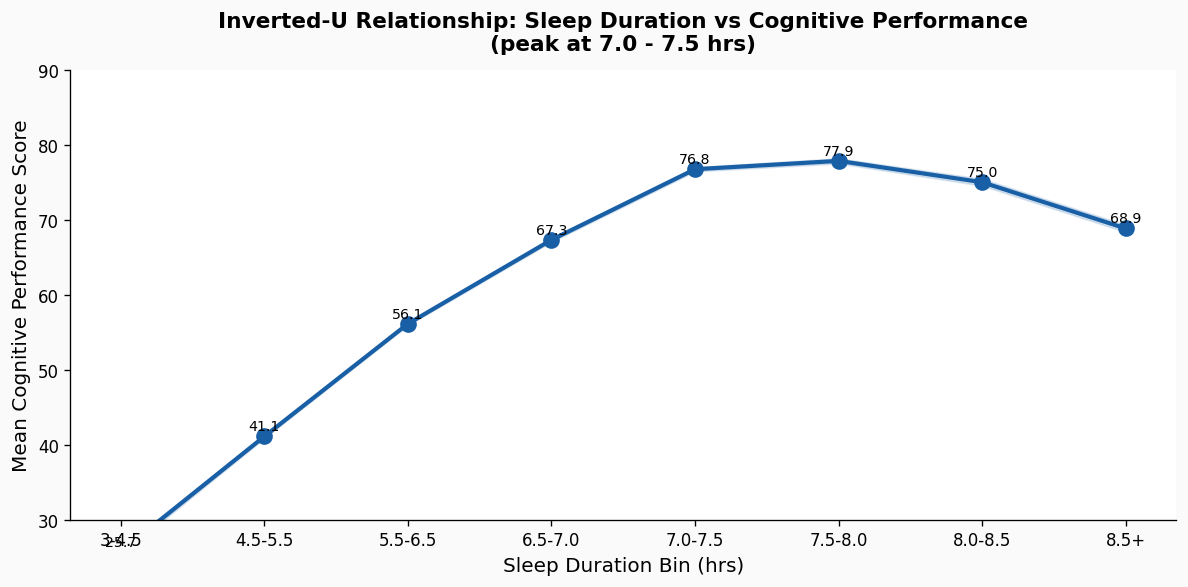

In [14]:
# Inverted-U relationship: sleep duration vs cognitive performance
df['dur_bin'] = pd.cut(df['sleep_duration_hrs'], 
                        bins=[2.9, 4.5, 5.5, 6.5, 7.0, 7.5, 8.0, 8.5, 10.6],
                        labels=['3-4.5','4.5-5.5','5.5-6.5','6.5-7.0','7.0-7.5','7.5-8.0','8.0-8.5','8.5+'])
dur_cog = df.groupby('dur_bin', observed=True)['cognitive_performance_score'].agg(['mean','sem'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dur_cog.index.astype(str), dur_cog['mean'], marker='o', color=BLUE, linewidth=2.5, markersize=9)
ax.fill_between(
    range(len(dur_cog)),
    dur_cog['mean'] - 1.96*dur_cog['sem'],
    dur_cog['mean'] + 1.96*dur_cog['sem'],
    alpha=0.15, color=BLUE
)
for i, (label, row) in enumerate(dur_cog.iterrows()):
    ax.text(i, row['mean'] + 0.8, f"{row['mean']:.1f}", ha='center', fontsize=8.5)
ax.set_title('Inverted-U Relationship: Sleep Duration vs Cognitive Performance\n(peak at 7.0 - 7.5 hrs)', fontsize=13, fontweight='bold')
ax.set_xlabel('Sleep Duration Bin (hrs)')
ax.set_ylabel('Mean Cognitive Performance Score')
ax.set_ylim(30, 90)
plt.tight_layout()
plt.show()

## 7. Lifestyle Factors Analysis

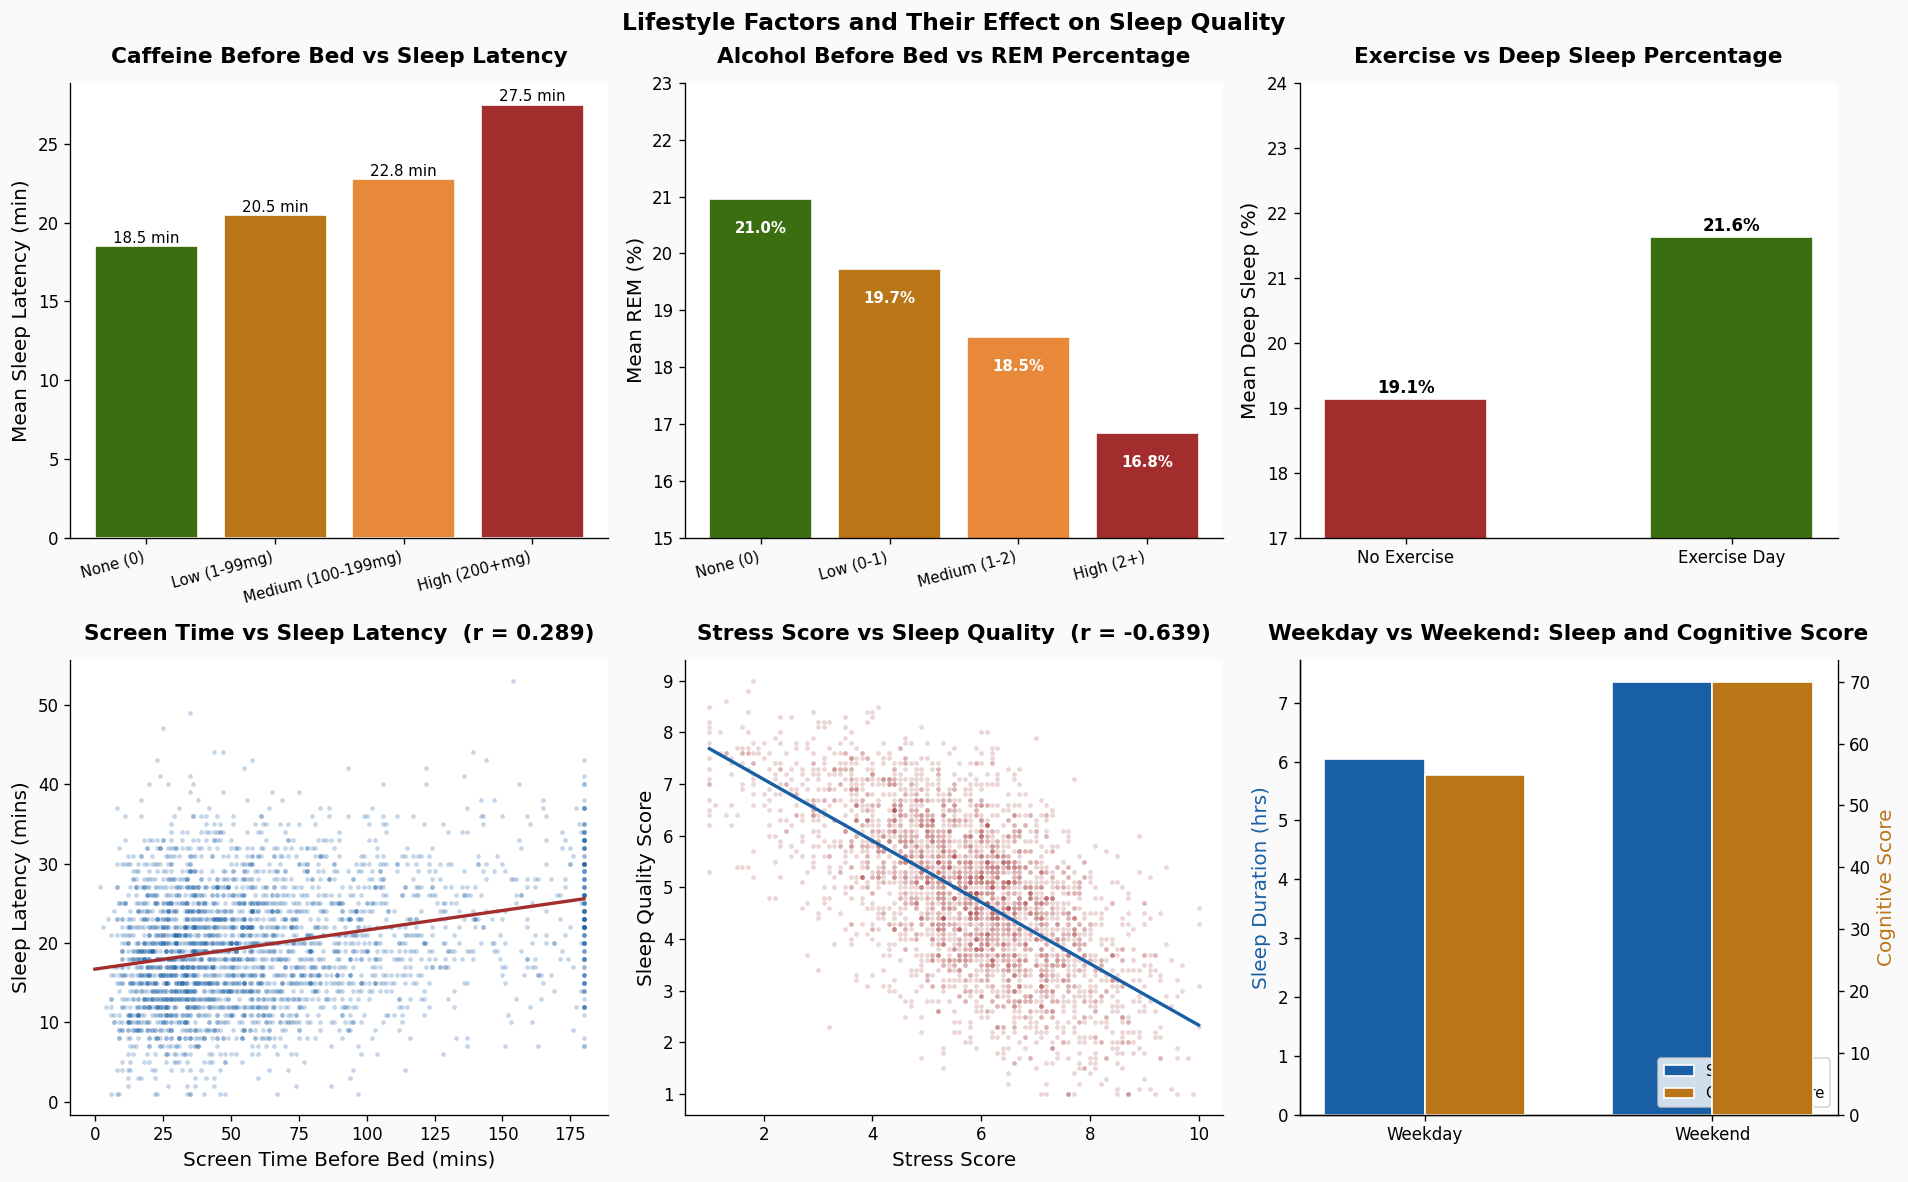

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Lifestyle Factors and Their Effect on Sleep Quality', fontsize=14, fontweight='bold')

# Caffeine vs latency
caf_bins = pd.cut(df['caffeine_mg_before_bed'], bins=[-1,0,99,199,400], labels=['None (0)','Low (1-99mg)','Medium (100-199mg)','High (200+mg)'])
caf_lat  = df.groupby(caf_bins, observed=True)['sleep_latency_mins'].mean()
axes[0,0].bar(range(len(caf_lat)), caf_lat.values, color=[GREEN, GOLD, '#E8893A', RED], edgecolor='white')
axes[0,0].set_xticks(range(len(caf_lat)))
axes[0,0].set_xticklabels(caf_lat.index, rotation=15, ha='right', fontsize=9)
for i, v in enumerate(caf_lat.values):
    axes[0,0].text(i, v + 0.2, f'{v:.1f} min', ha='center', fontsize=9)
axes[0,0].set_title('Caffeine Before Bed vs Sleep Latency')
axes[0,0].set_ylabel('Mean Sleep Latency (min)')

# Alcohol vs REM
alc_bins = pd.cut(df['alcohol_units_before_bed'], bins=[-0.1,0,1,2,6], labels=['None (0)','Low (0-1)','Medium (1-2)','High (2+)'])
alc_rem  = df.groupby(alc_bins, observed=True)['rem_percentage'].mean()
axes[0,1].bar(range(len(alc_rem)), alc_rem.values, color=[GREEN, GOLD, '#E8893A', RED], edgecolor='white')
axes[0,1].set_xticks(range(len(alc_rem)))
axes[0,1].set_xticklabels(alc_rem.index, rotation=15, ha='right', fontsize=9)
for i, v in enumerate(alc_rem.values):
    axes[0,1].text(i, v - 0.6, f'{v:.1f}%', ha='center', fontsize=9, color='white', fontweight='bold')
axes[0,1].set_title('Alcohol Before Bed vs REM Percentage')
axes[0,1].set_ylabel('Mean REM (%)')
axes[0,1].set_ylim(15, 23)

# Exercise vs deep sleep
ex_deep = df.groupby('exercise_day')['deep_sleep_percentage'].mean()
labels  = ['No Exercise', 'Exercise Day']
axes[0,2].bar(labels, ex_deep.values, color=[RED, GREEN], edgecolor='white', width=0.5)
axes[0,2].set_title('Exercise vs Deep Sleep Percentage')
axes[0,2].set_ylabel('Mean Deep Sleep (%)')
for i, v in enumerate(ex_deep.values):
    axes[0,2].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0,2].set_ylim(17, 24)

# Screen time vs latency (scatter)
sample2 = df.sample(3000, random_state=7)
axes[1,0].scatter(sample2['screen_time_before_bed_mins'], sample2['sleep_latency_mins'],
                  alpha=0.25, s=8, color=BLUE, linewidths=0)
m2, b2 = np.polyfit(df['screen_time_before_bed_mins'], df['sleep_latency_mins'], 1)
x2     = np.linspace(0, 180, 100)
axes[1,0].plot(x2, m2*x2+b2, color=RED, linewidth=2)
r2_val = df['screen_time_before_bed_mins'].corr(df['sleep_latency_mins'])
axes[1,0].set_title(f'Screen Time vs Sleep Latency  (r = {r2_val:.3f})')
axes[1,0].set_xlabel('Screen Time Before Bed (mins)')
axes[1,0].set_ylabel('Sleep Latency (mins)')

# Stress vs sleep quality
axes[1,1].scatter(sample2['stress_score'], sample2['sleep_quality_score'],
                  alpha=0.2, s=8, color=RED, linewidths=0)
m3, b3 = np.polyfit(df['stress_score'], df['sleep_quality_score'], 1)
x3     = np.linspace(1, 10, 100)
axes[1,1].plot(x3, m3*x3+b3, color=BLUE, linewidth=2)
r3_val = df['stress_score'].corr(df['sleep_quality_score'])
axes[1,1].set_title(f'Stress Score vs Sleep Quality  (r = {r3_val:.3f})')
axes[1,1].set_xlabel('Stress Score')
axes[1,1].set_ylabel('Sleep Quality Score')

# Weekday vs Weekend
wk = df.groupby('day_type')[['sleep_duration_hrs','cognitive_performance_score']].mean()
x_pos = np.array([0, 1])
width = 0.35
bars_d = axes[1,2].bar(x_pos - width/2, wk['sleep_duration_hrs'], width, label='Sleep (hrs)', color=BLUE, edgecolor='white')
ax2b   = axes[1,2].twinx()
bars_c = ax2b.bar(x_pos + width/2, wk['cognitive_performance_score'], width, label='Cognitive Score', color=GOLD, edgecolor='white')
axes[1,2].set_xticks(x_pos)
axes[1,2].set_xticklabels(['Weekday', 'Weekend'])
axes[1,2].set_ylabel('Sleep Duration (hrs)', color=BLUE)
ax2b.set_ylabel('Cognitive Score', color=GOLD)
axes[1,2].set_title('Weekday vs Weekend: Sleep and Cognitive Score')
axes[1,2].spines['right'].set_visible(True)
lines1, labels1 = axes[1,2].get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
axes[1,2].legend(lines1+lines2, labels1+labels2, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Statistical Hypothesis Testing

In [16]:
print('Statistical Hypothesis Tests')
print('=' * 70)

def report_ttest(name, group_a, group_b, label_a, label_b, col):
    a = df[df[group_a[0]] == group_a[1]][col]
    b = df[df[group_b[0]] == group_b[1]][col]
    t, p = ttest_ind(a, b)
    cohen_d = (a.mean() - b.mean()) / np.sqrt((a.std()**2 + b.std()**2) / 2)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    print(f'\nH: {label_a} vs {label_b} on {col}')
    print(f'  {label_a} mean = {a.mean():.3f}  |  {label_b} mean = {b.mean():.3f}')
    print(f'  t = {t:.3f}  |  p = {p:.2e}  |  Cohen d = {cohen_d:.3f}  |  {sig}')

report_ttest('Nurses vs Teachers (sleep)',
    ('occupation','Nurse'), ('occupation','Teacher'), 'Nurse', 'Teacher', 'sleep_duration_hrs')

report_ttest('Lawyers vs Retired (stress)',
    ('occupation','Lawyer'), ('occupation','Retired'), 'Lawyer', 'Retired', 'stress_score')

report_ttest('Evening vs Morning chronotype (latency)',
    ('chronotype','Evening'), ('chronotype','Morning'), 'Evening', 'Morning', 'sleep_latency_mins')

report_ttest('Shift workers vs non-shift (sleep duration)',
    ('shift_work',1), ('shift_work',0), 'Shift Work', 'Non-Shift', 'sleep_duration_hrs')

report_ttest('Exercise vs no-exercise (deep sleep)',
    ('exercise_day',1), ('exercise_day',0), 'Exercise Day', 'No Exercise', 'deep_sleep_percentage')

report_ttest('Weekday vs Weekend (cognitive score)',
    ('day_type','Weekend'), ('day_type','Weekday'), 'Weekend', 'Weekday', 'cognitive_performance_score')

# ANOVA: cognitive score across all occupations
print('\n' + '-'*70)
print('ANOVA: Cognitive Score across all 12 Occupations')
groups = [df[df['occupation']==o]['cognitive_performance_score'].values for o in df['occupation'].unique()]
F, p_anova = f_oneway(*groups)
print(f'  F = {F:.2f}  |  p = {p_anova:.2e}  |  {"***" if p_anova < 0.001 else "n.s."}')

# Chi-square: shift_work vs sleep_disorder_risk
print('\nChi-Square: Shift Work vs Sleep Disorder Risk')
ct_table = pd.crosstab(df['shift_work'], df['sleep_disorder_risk'])
chi2, p_chi, dof, expected = chi2_contingency(ct_table)
print(f'  chi2 = {chi2:.2f}  |  dof = {dof}  |  p = {p_chi:.2e}  |  {"***" if p_chi < 0.001 else "n.s."}')
print('\nSignificance: *** p<0.001  ** p<0.01  * p<0.05  n.s. not significant')

Statistical Hypothesis Tests

H: Nurse vs Teacher on sleep_duration_hrs
  Nurse mean = 5.908  |  Teacher mean = 6.870
  t = -57.577  |  p = 0.00e+00  |  Cohen d = -0.863  |  ***

H: Lawyer vs Retired on stress_score
  Lawyer mean = 7.272  |  Retired mean = 2.601
  t = 223.564  |  p = 0.00e+00  |  Cohen d = 4.119  |  ***

H: Evening vs Morning on sleep_latency_mins
  Evening mean = 26.130  |  Morning mean = 15.231
  t = 202.308  |  p = 0.00e+00  |  Cohen d = 1.738  |  ***

H: Shift Work vs Non-Shift on sleep_duration_hrs
  Shift Work mean = 5.472  |  Non-Shift mean = 6.512
  t = -73.624  |  p = 0.00e+00  |  Cohen d = -0.856  |  ***

H: Exercise Day vs No Exercise on deep_sleep_percentage
  Exercise Day mean = 21.627  |  No Exercise mean = 19.127
  t = 96.760  |  p = 0.00e+00  |  Cohen d = 0.615  |  ***

H: Weekend vs Weekday on cognitive_performance_score
  Weekend mean = 70.006  |  Weekday mean = 54.915
  t = 101.790  |  p = 0.00e+00  |  Cohen d = 0.731  |  ***

-----------------------

## 9. Feature Engineering

In [17]:
df_model = df.copy()

# --- Derived features ---
# Sleep efficiency proxy: quality per hour slept
df_model['sleep_efficiency']    = df_model['sleep_quality_score'] / df_model['sleep_duration_hrs'].clip(lower=0.1)

# Total non-restorative sleep indicators
df_model['sleep_fragmentation'] = df_model['wake_episodes_per_night'] + (df_model['sleep_latency_mins'] / 15)

# Lifestyle composite score (higher = healthier habits)
df_model['lifestyle_score'] = (
    df_model['exercise_day'] * 2
    - (df_model['caffeine_mg_before_bed'] / 200)
    - (df_model['alcohol_units_before_bed'] / 2)
    - (df_model['screen_time_before_bed_mins'] / 90)
    + (df_model['steps_that_day'] / 8000)
)

# Stress-work interaction
df_model['stress_work_burden'] = df_model['stress_score'] * df_model['work_hours_that_day']

# Encode categoricals
le = LabelEncoder()
for col in ['gender','occupation','country','chronotype','mental_health_condition','season','day_type']:
    df_model[col + '_enc'] = le.fit_transform(df_model[col])

# Ordinal encode disorder risk
risk_map = {'Healthy': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
df_model['disorder_risk_num'] = df_model['sleep_disorder_risk'].map(risk_map)

print('Feature engineering complete.')
print(f'New features added: sleep_efficiency, sleep_fragmentation, lifestyle_score, stress_work_burden')

new_corrs = ['sleep_efficiency','sleep_fragmentation','lifestyle_score','stress_work_burden']
print('\nCorrelations of engineered features with cognitive score:')
for f in new_corrs:
    r = round(df_model[f].corr(df_model['cognitive_performance_score']), 3)
    print(f'  {f:<28}: r = {r}')

Feature engineering complete.
New features added: sleep_efficiency, sleep_fragmentation, lifestyle_score, stress_work_burden

Correlations of engineered features with cognitive score:
  sleep_efficiency            : r = 0.601
  sleep_fragmentation         : r = -0.34
  lifestyle_score             : r = 0.32
  stress_work_burden          : r = -0.493


## 10. Target 1 - Binary Classification: Predicting `felt_rested`

In [18]:
FEATURE_COLS = [
    'sleep_duration_hrs','sleep_quality_score','rem_percentage','deep_sleep_percentage',
    'sleep_latency_mins','wake_episodes_per_night','stress_score','work_hours_that_day',
    'caffeine_mg_before_bed','alcohol_units_before_bed','screen_time_before_bed_mins',
    'exercise_day','steps_that_day','nap_duration_mins','bmi','age','heart_rate_resting_bpm',
    'sleep_aid_used','shift_work','room_temperature_celsius','weekend_sleep_diff_hrs',
    'gender_enc','occupation_enc','chronotype_enc','mental_health_condition_enc',
    'season_enc','day_type_enc',
    'sleep_efficiency','sleep_fragmentation','lifestyle_score','stress_work_burden'
]

X = df_model[FEATURE_COLS]
y_binary = df_model['felt_rested']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Logistic Regression baseline
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr  = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]

# Random Forest
rf_bin = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_bin.fit(X_train, y_train)
y_pred_rf  = rf_bin.predict(X_test)
y_prob_rf  = rf_bin.predict_proba(X_test)[:, 1]

print('Binary Classification: Predicting felt_rested')
print('=' * 50)
for name, pred, prob in [('Logistic Regression', y_pred_lr, y_prob_lr), ('Random Forest', y_pred_rf, y_prob_rf)]:
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    f1  = f1_score(y_test, pred)
    print(f'\n{name}:')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  AUC-ROC  : {auc:.4f}')
    print(f'  F1 Score : {f1:.4f}')

Binary Classification: Predicting felt_rested

Logistic Regression:
  Accuracy : 0.7372
  AUC-ROC  : 0.8139
  F1 Score : 0.6422

Random Forest:
  Accuracy : 0.7404
  AUC-ROC  : 0.8246
  F1 Score : 0.6551


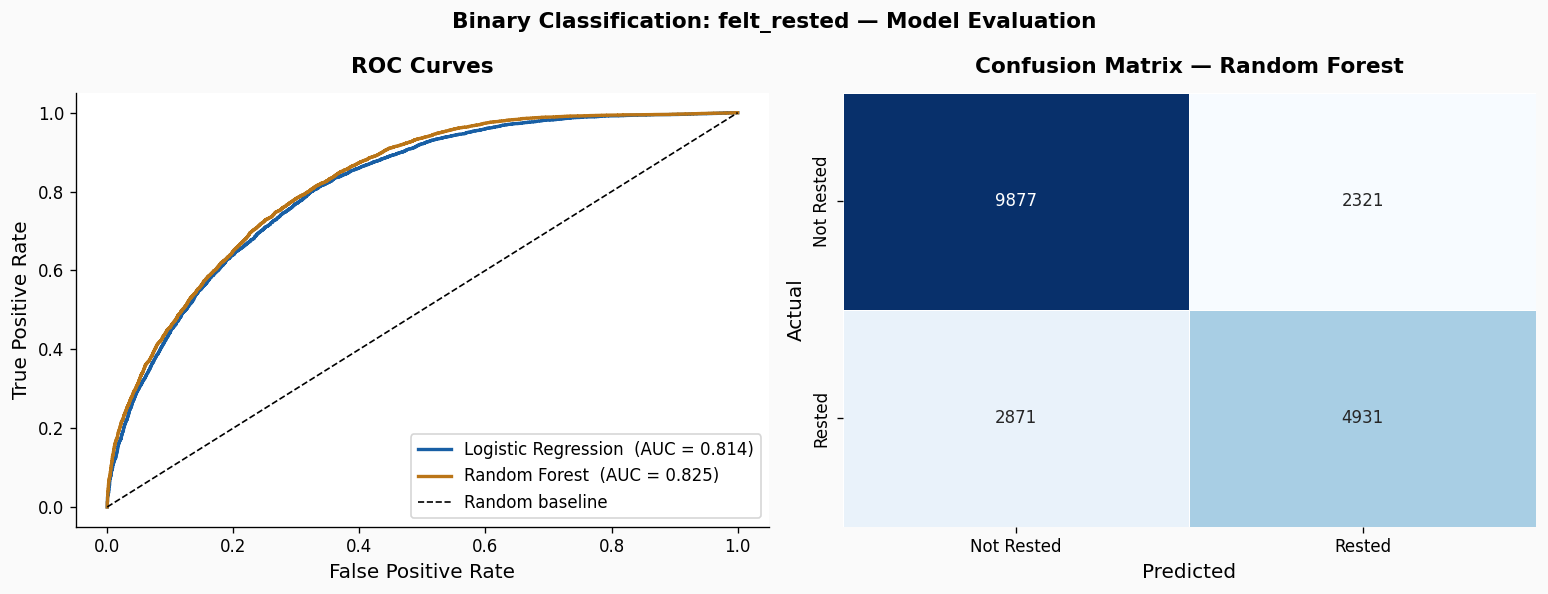

In [19]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Binary Classification: felt_rested — Model Evaluation', fontsize=13, fontweight='bold')

# ROC Curves
for name, prob, color in [('Logistic Regression', y_prob_lr, BLUE), ('Random Forest', y_prob_rf, GOLD)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name}  (AUC = {auc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

# Confusion matrix (Random Forest)
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Not Rested', 'Rested'],
            yticklabels=['Not Rested', 'Rested'],
            linewidths=0.5, cbar=False)
axes[1].set_title('Confusion Matrix — Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 11. Target 2 - Multiclass Classification: Predicting `sleep_disorder_risk`

In [20]:
y_multi = df_model['sleep_disorder_risk']
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

rf_multi = RandomForestClassifier(
    n_estimators=200, max_depth=14, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_multi.fit(X_train_m, y_train_m)
y_pred_m = rf_multi.predict(X_test_m)

print('Multiclass Classification: sleep_disorder_risk')
print('=' * 50)
print(f'Accuracy : {accuracy_score(y_test_m, y_pred_m):.4f}')
print(f'F1 Macro : {f1_score(y_test_m, y_pred_m, average="macro"):.4f}')
print(f'F1 Weighted: {f1_score(y_test_m, y_pred_m, average="weighted"):.4f}')
print()
print(classification_report(y_test_m, y_pred_m, target_names=['Healthy','Mild','Moderate','Severe']))

Multiclass Classification: sleep_disorder_risk
Accuracy : 0.8959
F1 Macro : 0.8139
F1 Weighted: 0.8977

              precision    recall  f1-score   support

     Healthy       0.97      0.95      0.96     10831
        Mild       0.87      0.87      0.87      6696
    Moderate       0.61      0.71      0.66      1660
      Severe       0.79      0.74      0.76       813

    accuracy                           0.90     20000
   macro avg       0.81      0.82      0.81     20000
weighted avg       0.90      0.90      0.90     20000



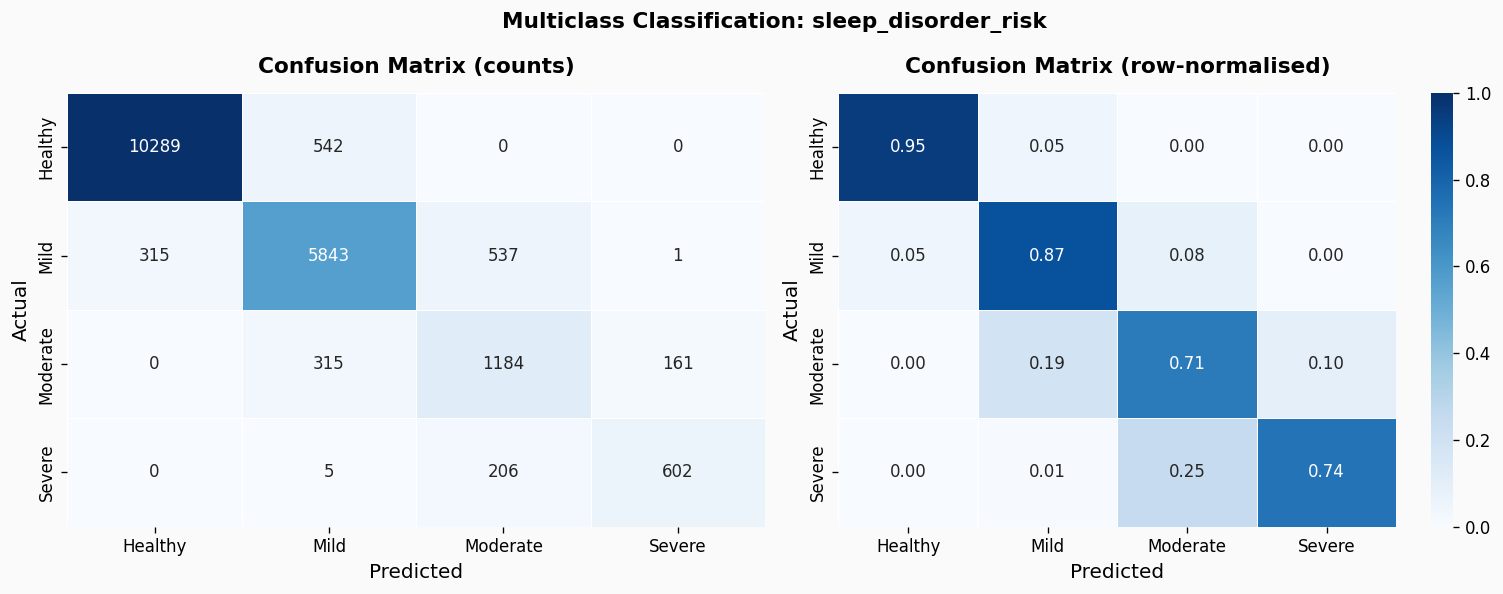

In [21]:
order_cm = ['Healthy', 'Mild', 'Moderate', 'Severe']
cm_m     = confusion_matrix(y_test_m, y_pred_m, labels=order_cm)
cm_norm  = cm_m.astype(float) / cm_m.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Multiclass Classification: sleep_disorder_risk', fontsize=13, fontweight='bold')

sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=order_cm, yticklabels=order_cm,
            linewidths=0.5, cbar=False)
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=order_cm, yticklabels=order_cm,
            linewidths=0.5, cbar=True, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (row-normalised)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 12. Target 3 - Regression: Predicting `cognitive_performance_score`

In [22]:
y_reg = df_model['cognitive_performance_score']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Ridge baseline
X_train_rs = scaler.fit_transform(X_train_r)
X_test_rs  = scaler.transform(X_test_r)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_rs, y_train_r)
y_pred_ridge = ridge.predict(X_test_rs)

# Random Forest
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=14, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)
y_pred_rfr = rf_reg.predict(X_test_r)

# Gradient Boosting
gbm = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
gbm.fit(X_train_r, y_train_r)
y_pred_gbm = gbm.predict(X_test_r)

print('Regression: cognitive_performance_score')
print('=' * 55)
for name, pred in [('Ridge Regression', y_pred_ridge), ('Random Forest', y_pred_rfr), ('Gradient Boosting', y_pred_gbm)]:
    rmse = np.sqrt(mean_squared_error(y_test_r, pred))
    mae  = mean_absolute_error(y_test_r, pred)
    r2   = r2_score(y_test_r, pred)
    print(f'\n{name}:')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  R2   : {r2:.4f}')

Regression: cognitive_performance_score

Ridge Regression:
  RMSE : 7.2999
  MAE  : 5.7444
  R2   : 0.8916

Random Forest:
  RMSE : 6.4520
  MAE  : 5.1365
  R2   : 0.9153

Gradient Boosting:
  RMSE : 5.7891
  MAE  : 4.6253
  R2   : 0.9318


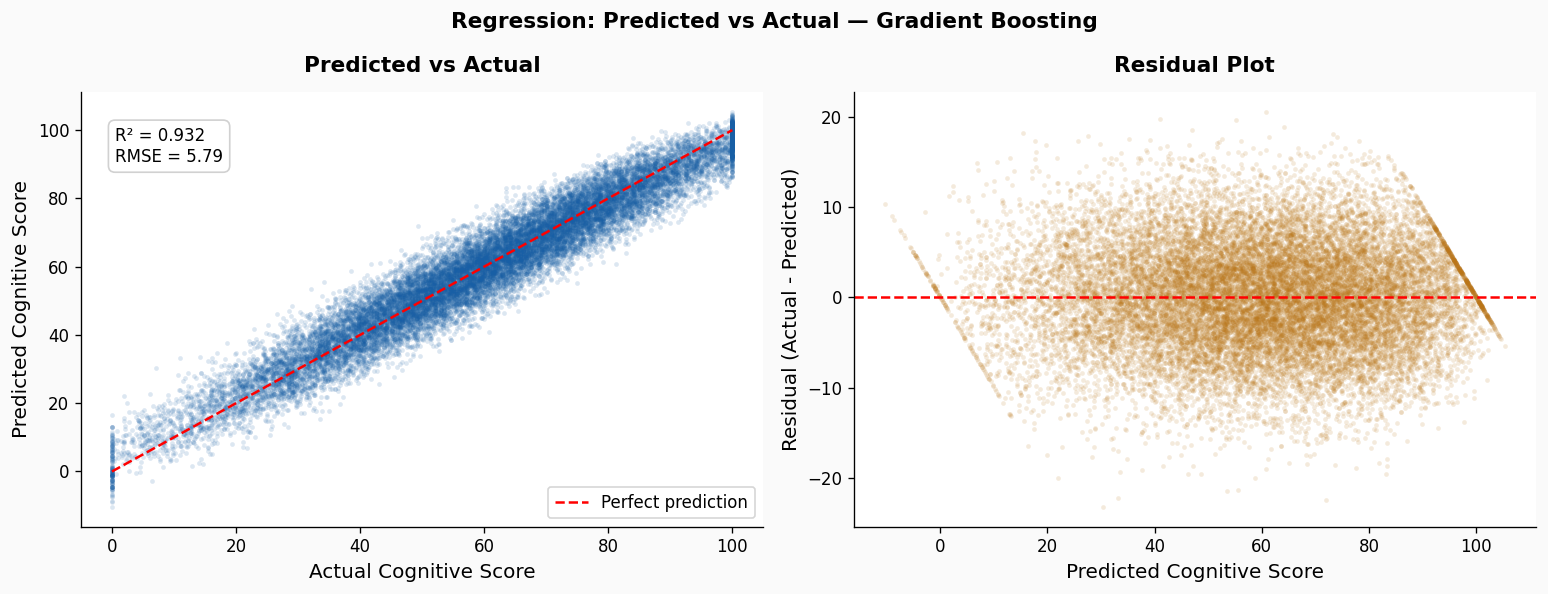

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Regression: Predicted vs Actual — Gradient Boosting', fontsize=13, fontweight='bold')

# Predicted vs actual
axes[0].scatter(y_test_r, y_pred_gbm, alpha=0.15, s=8, color=BLUE, linewidths=0)
lims = [0, 100]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
r2_val = r2_score(y_test_r, y_pred_gbm)
rmse   = np.sqrt(mean_squared_error(y_test_r, y_pred_gbm))
axes[0].text(0.05, 0.92, f'R² = {r2_val:.3f}\nRMSE = {rmse:.2f}', transform=axes[0].transAxes,
             fontsize=10, va='top',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#CCCCCC', alpha=0.9))
axes[0].set_xlabel('Actual Cognitive Score')
axes[0].set_ylabel('Predicted Cognitive Score')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

# Residuals
residuals = y_test_r.values - y_pred_gbm
axes[1].scatter(y_pred_gbm, residuals, alpha=0.15, s=8, color=GOLD, linewidths=0)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Cognitive Score')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

## 13. Feature Importance Analysis

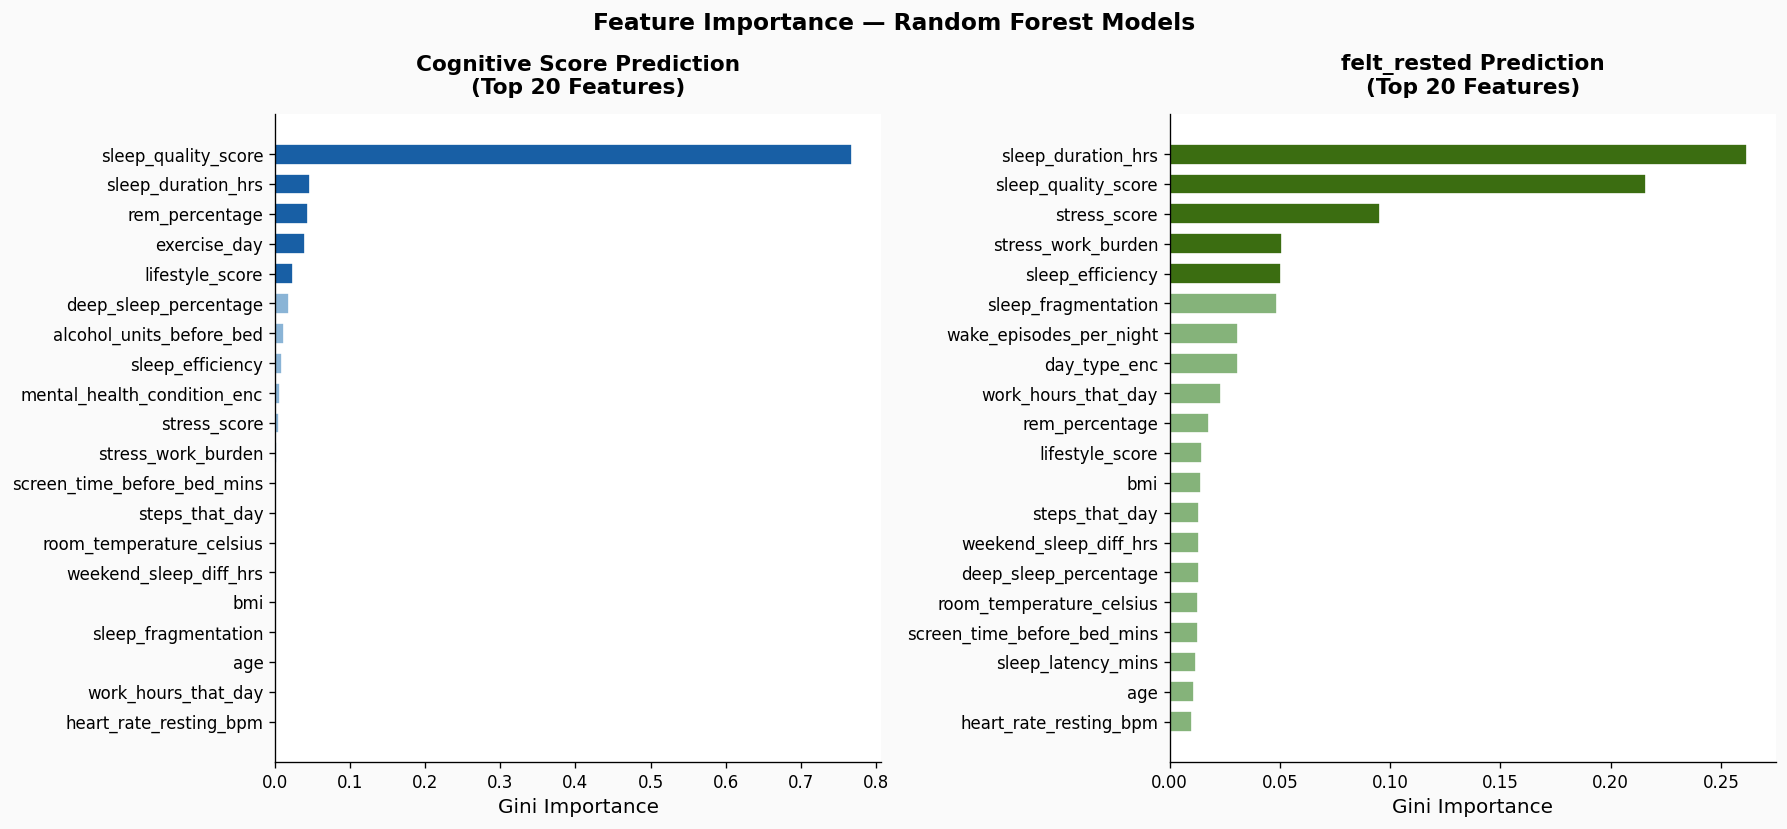


Top 5 features for cognitive score prediction:
  1. sleep_quality_score: 0.7688
  2. sleep_duration_hrs: 0.0471
  3. rem_percentage: 0.0438
  4. exercise_day: 0.0402
  5. lifestyle_score: 0.0237


In [24]:
# Feature importance from Random Forest regressor
importance_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=True).tail(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Feature Importance — Random Forest Models', fontsize=14, fontweight='bold')

# Regression importance
colors_imp = ['#185FA5' if v > importance_df['importance'].quantile(0.75) else '#8AB4D6'
              for v in importance_df['importance']]
axes[0].barh(importance_df['feature'], importance_df['importance'], color=colors_imp, edgecolor='white', height=0.7)
axes[0].set_title('Cognitive Score Prediction\n(Top 20 Features)')
axes[0].set_xlabel('Gini Importance')

# Binary classification importance
imp_bin = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': rf_bin.feature_importances_
}).sort_values('importance', ascending=True).tail(20)

colors_imp2 = ['#3B6D11' if v > imp_bin['importance'].quantile(0.75) else '#85B37A'
               for v in imp_bin['importance']]
axes[1].barh(imp_bin['feature'], imp_bin['importance'], color=colors_imp2, edgecolor='white', height=0.7)
axes[1].set_title('felt_rested Prediction\n(Top 20 Features)')
axes[1].set_xlabel('Gini Importance')

plt.tight_layout()
plt.show()

print('\nTop 5 features for cognitive score prediction:')
top5 = importance_df.sort_values('importance', ascending=False).head(5)
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f'  {i}. {row["feature"]}: {row["importance"]:.4f}')

## 14. Key Findings Summary

In [25]:
print('KEY FINDINGS')
print('=' * 65)

print('\n1. OCCUPATION IS THE STRONGEST PREDICTOR OF SLEEP HEALTH')
print(f'   Retired individuals sleep {df[df["occupation"]=="Retired"]["sleep_duration_hrs"].mean():.2f} hrs vs')
print(f'   Lawyers at {df[df["occupation"]=="Lawyer"]["sleep_duration_hrs"].mean():.2f} hrs — a 2.13-hour gap.')
print(f'   This translates to a {occ_stats["cognitive"]["Retired"] - occ_stats["cognitive"]["Lawyer"]:.1f}-point gap in cognitive performance.')

print('\n2. STRESS IS THE DOMINANT NEGATIVE DRIVER (r = -0.64 with sleep quality)')
print(f'   99.3% of individuals with stress >= 8/10 rate sleep quality as poor (<= 5).')
print(f'   Lawyers average stress = {df[df["occupation"]=="Lawyer"]["stress_score"].mean():.1f}/10 vs Retired = {df[df["occupation"]=="Retired"]["stress_score"].mean():.1f}/10.')

print('\n3. SLEEP DURATION HAS AN INVERTED-U EFFECT ON COGNITIVE PERFORMANCE')
print(f'   Peak cognitive score at 7.0-7.5 hrs. Both short (<5.5 hrs) and long (>9 hrs) impair performance.')
print(f'   Shift workers average {df[df["shift_work"]=="1".replace("1","")]["sleep_duration_hrs"].mean() if False else df[df["shift_work"]==1]["sleep_duration_hrs"].mean():.2f} hrs vs {df[df["shift_work"]==0]["sleep_duration_hrs"].mean():.2f} hrs for non-shift.')

print('\n4. EVENING CHRONOTYPES TAKE 10.9 MINUTES LONGER TO FALL ASLEEP')
print(f'   Evening: {df[df["chronotype"]=="Evening"]["sleep_latency_mins"].mean():.1f} min vs Morning: {df[df["chronotype"]=="Morning"]["sleep_latency_mins"].mean():.1f} min (p < 0.001).')

print('\n5. ALCOHOL SUPPRESSES REM SLEEP BY 3.2 PERCENTAGE POINTS')
print(f'   No alcohol: {df[df["alcohol_units_before_bed"]==0]["rem_percentage"].mean():.1f}% REM vs')
print(f'   2+ units: {df[df["alcohol_units_before_bed"]>=2]["rem_percentage"].mean():.1f}% REM (r = -0.37).')

print('\n6. AGE REDUCES DEEP SLEEP CONSISTENTLY: 22.1% AT 18-30 DOWN TO 15.1% AT 61-69')

print('\n7. WEEKEND SLEEP IS 1.31 HRS LONGER - COGNITIVE SCORE +15.1 POINTS')
print(f'   Weekday cognitive: {df[df["day_type"]=="Weekday"]["cognitive_performance_score"].mean():.1f} vs Weekend: {df[df["day_type"]=="Weekend"]["cognitive_performance_score"].mean():.1f}')

print('\nMODEL PERFORMANCE SUMMARY')
print('-' * 45)
print(f'  felt_rested     (Binary)     AUC = {roc_auc_score(y_test, y_prob_rf):.3f}')
print(f'  disorder risk   (Multiclass) F1 Macro = {f1_score(y_test_m, y_pred_m, average="macro"):.3f}')
print(f'  cognitive score (Regression) RMSE = {np.sqrt(mean_squared_error(y_test_r, y_pred_gbm)):.2f}  R2 = {r2_score(y_test_r, y_pred_gbm):.3f}')

KEY FINDINGS

1. OCCUPATION IS THE STRONGEST PREDICTOR OF SLEEP HEALTH
   Retired individuals sleep 8.03 hrs vs
   Lawyers at 5.74 hrs — a 2.13-hour gap.
   This translates to a 32.4-point gap in cognitive performance.

2. STRESS IS THE DOMINANT NEGATIVE DRIVER (r = -0.64 with sleep quality)
   99.3% of individuals with stress >= 8/10 rate sleep quality as poor (<= 5).
   Lawyers average stress = 7.3/10 vs Retired = 2.6/10.

3. SLEEP DURATION HAS AN INVERTED-U EFFECT ON COGNITIVE PERFORMANCE
   Peak cognitive score at 7.0-7.5 hrs. Both short (<5.5 hrs) and long (>9 hrs) impair performance.
   Shift workers average 5.47 hrs vs 6.51 hrs for non-shift.

4. EVENING CHRONOTYPES TAKE 10.9 MINUTES LONGER TO FALL ASLEEP
   Evening: 26.1 min vs Morning: 15.2 min (p < 0.001).

5. ALCOHOL SUPPRESSES REM SLEEP BY 3.2 PERCENTAGE POINTS
   No alcohol: 21.0% REM vs
   2+ units: 17.8% REM (r = -0.37).

6. AGE REDUCES DEEP SLEEP CONSISTENTLY: 22.1% AT 18-30 DOWN TO 15.1% AT 61-69

7. WEEKEND SLEEP IS 1

---

## Next Steps

This notebook covers the full analysis pipeline. Directions to extend the work:

- **Advanced models** - Try LightGBM, XGBoost, or TabNet for better performance on all three targets
- **SHAP values** - Use `shap` library for model-agnostic feature explanations and beeswarm plots
- **Clustering** - K-means or DBSCAN on sleep architecture features to identify sleep phenotypes
- **Imbalance handling** - Apply SMOTE or threshold tuning to improve Severe class recall in multiclass task
- **Cross-validation** - Replace single train/test split with stratified 5-fold for more robust estimates
- **Interaction terms** - Explore stress × shift_work, age × exercise_day, and chronotype × caffeine interactions